# Model Demonstration — Direct CO₂ Hydrogenation Kinetic Model

This notebook is the easiest way to understand and operate the project.

The workflow is:

**operating conditions → inlet molar flows → kinetic rates → packed-bed ODE → outlet composition → validation**

The underlying equations are kept in three small Python files under `model/` so that the notebook stays readable.

## 1. Reaction network

The model tracks ten species:

`CO2, H2, CH3OH, H2O, CO, C2H6, C3H8, C4H10, CH4, He`

and seven reactions:

1. CO₂ + 3 H₂ ⇌ CH₃OH + H₂O  
2. CO₂ + H₂ ⇌ CO + H₂O  
3. CO + 2 H₂ ⇌ CH₃OH  
4. CO + 3 H₂ → CH₄ + H₂O  
5. 2 CH₃OH + H₂ → C₂H₆ + 2 H₂O  
6. 3 CH₃OH + H₂ → C₃H₈ + 3 H₂O  
7. 4 CH₃OH + H₂ → C₄H₁₀ + 4 H₂O

Helium is treated as an inert internal standard (check publication).

In [25]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model.kinetics import SPECIES, REACTIONS, calculate_reaction_rates
from model.reactor import create_inlet_from_space_time, solve_reactor, carbon_basis_fractions

print("Species order:")
print(SPECIES)

Species order:
['CO2', 'H2', 'CH3OH', 'H2O', 'CO', 'C2H6', 'C3H8', 'C4H10', 'CH4', 'He']


## 2. Choose operating conditions

Edit these values to explore a different reactor case. Temperature is entered in °C here and converted to K before solving the model.

In [26]:
TEMPERATURE_C = 350.0
PRESSURE_BAR = 40.0
SPACE_TIME = 24.0          # g_cat h / mol_COx
CATALYST_MASS_G = 1.0
H2_OVER_COX = 3.0
CO2_FRACTION_IN_COX = 1.0  # 1=pure CO2, 0.5=50/50 CO2/CO, 0=pure CO
HELIUM_FRACTION = 0.2

## 3. Build the inlet

For the validation convention,

$$
\tau = \frac{W}{F_{CO_x}}
$$

so the chosen space time and catalyst mass define the COx molar flow. The H₂/COx ratio fixes H₂, while the CO₂ fraction determines the split between CO₂ and CO.

In [27]:
inlet = create_inlet_from_space_time(
    SPACE_TIME,
    catalyst_mass_g=CATALYST_MASS_G,
    H2_over_COx=H2_OVER_COX,
    CO2_fraction_in_COx=CO2_FRACTION_IN_COX,
    helium_fraction=HELIUM_FRACTION,
)

pd.DataFrame({"species": SPECIES, "inlet_mol_s": inlet})

,species,inlet_mol_s
0,CO2,0.000012
1,H2,0.000035
2,CH3OH,0.000000
3,H2O,0.000000
4,CO,0.000000
5,C2H6,0.000000
6,C3H8,0.000000
7,C4H10,0.000000
8,CH4,0.000000
9,He,0.000012


## 4. Evaluate the kinetic rates at the reactor inlet

`model/kinetics.py` contains the seven kinetic expressions. The rates are returned in mol/(kg_cat·s).

In [28]:
inlet_rates = calculate_reaction_rates(inlet, TEMPERATURE_C + 273.15, PRESSURE_BAR)
pd.DataFrame({"reaction": REACTIONS, "rate_mol_kg_s": inlet_rates})

,reaction,rate_mol_kg_s
0,CO2 + 3 H2 <-> CH3OH + H2O,0.060401
1,CO2 + H2 <-> CO + H2O,0.005624
2,CO + 2 H2 <-> CH3OH,0.000000
3,CO + 3 H2 -> CH4 + H2O,0.000000
4,2 CH3OH + H2 -> C2H6 + 2 H2O,0.000000
5,3 CH3OH + H2 -> C3H8 + 3 H2O,0.000000
6,4 CH3OH + H2 -> C4H10 + 4 H2O,0.000000


## 5. Solve the packed-bed reactor

The reactor balance is

$$
\frac{dF_i}{dW} = r_i
$$

with catalyst mass \(W\) as the independent coordinate. The model is isothermal and isobaric.

In [29]:
W, F = solve_reactor(
    CATALYST_MASS_G / 1000.0,
    inlet,
    TEMPERATURE_C + 273.15,
    PRESSURE_BAR,
)

outlet = F[:, -1]
print(f"Integrated {len(W)} catalyst-mass points.")

Integrated 1004 catalyst-mass points.


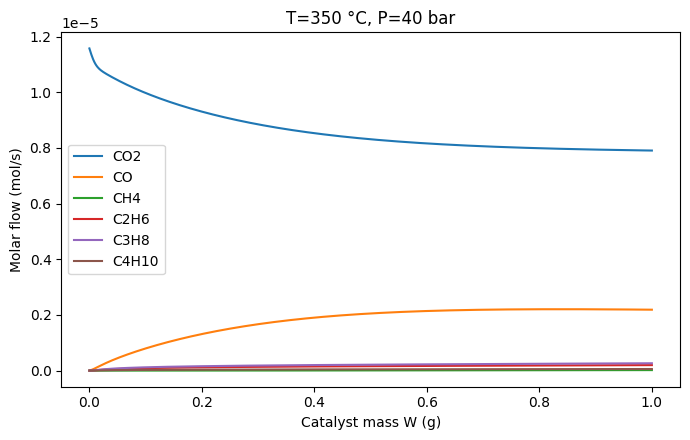

In [30]:
plt.figure(figsize=(7, 4.5))
for index in [0, 4, 8, 5, 6, 7]:
    plt.plot(W * 1000.0, F[index], label=SPECIES[index])

plt.xlabel("Catalyst mass W (g)")
plt.ylabel("Molar flow (mol/s)")
plt.title(f"T={TEMPERATURE_C:.0f} °C, P={PRESSURE_BAR:.0f} bar")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Outlet composition on a carbon basis

The literature validation plots compare CO₂, CO and C₁–C₄ products on a carbon basis. For example, C₃H₈ contributes three carbon moles per mole of propane.

In [31]:
carbon_outlet = carbon_basis_fractions(outlet)
pd.DataFrame({"carbon_basis_fraction": carbon_outlet})

,carbon_basis_fraction
CO2,0.685723
CO,0.189811
C1,0.001601
C2,0.034211
C3,0.068803
C4,0.019851


## 7. Compare one case with digitized validation data

The CSV files in `data/` contain the digitized points used for the S4/S5 comparisons. This example reproduces the S4a case (325 °C, 40 bar, pure CO₂ feed).

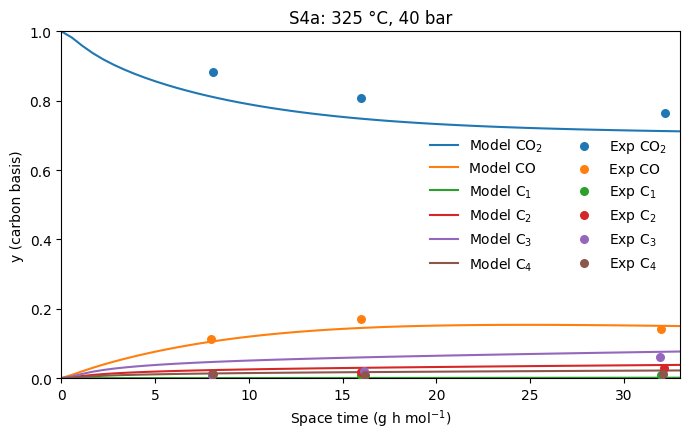

In [32]:
from reproduce_validation import plot_validation_panel

fig, ax = plt.subplots(figsize=(7, 4.5))
plot_validation_panel(
    ax,
    T_C=325,
    P_bar=40,
    CO2_fraction=1.0,
    CO_fraction=0.0,
    tau_max=33,
    n_points=60,
    csv_file="S4a_325C_40bar_CO2.csv",
)
ax.set_title("S4a: 325 °C, 40 bar")
fig.tight_layout()
plt.show()

## 8. Reproduce the complete validation set

From a terminal opened in the repository root, run:

```bash
python reproduce_validation.py
```

This generates:

- `figures/S4_validation.png`
- `figures/S5_validation.png`
- `figures/Figure5a_water_profile.png`
- `figures/Figure5b_reaction_rates.png`

If you want to understand the implementation itself, read the code next in this order:

1. `model/equilibrium.py`
2. `model/kinetics.py`
3. `model/reactor.py`
4. `reproduce_validation.py`
